# 5.5 Patient Subtyping & Clustering (V2 - Comprehensive Analysis)

This notebook performs a rigorous clustering analysis to identify distinct **patient subtypes** based on VAE latent representations.
It addresses the limitations of V1 by implementing:

## Methodology Improvements (V2)
1. **Dimensionality Reduction Prior to Clustering**: 
   - PCA to reduce 70 active dimensions to ~10-15 components
   - UMAP for manifold-aware 2D projection
2. **Multiple Clustering Algorithms**:
   - K-Means (baseline)
   - GMM with Full Covariance (probabilistic, allows elliptical clusters)
   - Agglomerative Hierarchical Clustering (with dendrogram)
3. **Cluster Validation**:
   - Silhouette Score (internal quality)
   - Adjusted Rand Index (alignment with PD/Control labels)
   - Gap Statistic (optimal k selection)
4. **Cluster Stability Analysis**:
   - Bootstrap Consensus Clustering to verify robustness
5. **Clinical Profiling**:
   - Heatmap comparing clusters on Age, SBR_PC1, SBR_PC2, Disease Status
   - Statistical tests (ANOVA/Chi-Square) to identify defining features

## Factors Analyzed (from 5.1.1)
- **Confounders to Exclude**: Age, Sex, Scanner, Manufacturer
- **Disease Markers to Include**: SBR_PC1, SBR_PC2, SBR_PC3
- **Clinical Outcomes**: PD vs Control (label)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy import stats
import os
import warnings

# Optional: UMAP (install with: pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("Warning: UMAP not installed. Install with: pip install umap-learn")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: '%.4f' % x)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Loading & Feature Engineering

In [11]:
# --- PARAMETERS ---
LATENT_CSV = "output/final_train_combined_vae_data.csv"
CORR_SUMMARY_CSV = "output/strict_correlation_analysis_summary.csv"
KL_CSV_PATH = "output/Experiments/BetaScanVAE/beta_scan_results/beta_3.00e-05/kl_divergence.csv"
KL_THRESHOLD = 0.05

# SBR columns for PCA
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Confounder dimensions (from 5.1.1 analysis) - TO BE EXCLUDED
CONFOUNDER_DIMS = ['latent_72', 'latent_133', 'latent_39', 'latent_39', 'latent_142', 'latent_126', 'latent_163', 'latent_155']

# Load Main Data
if os.path.exists(LATENT_CSV):
    df_latent = pd.read_csv(LATENT_CSV)
    print(f"Loaded Latent Data: {df_latent.shape}")
else:
    raise FileNotFoundError(f"Latent data not found at {LATENT_CSV}")

# Define Latent Columns
DIM_COLS = [c for c in df_latent.columns if c.startswith('latent_')]
print(f"Total Latent Dimensions: {len(DIM_COLS)}")

Loaded Latent Data: (2373, 303)
Total Latent Dimensions: 256


In [12]:
# Create SBR Principal Components
df_with_sbr = df_latent.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca_sbr = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca_sbr.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca_sbr.explained_variance_ratio_}")
print(f"Total variance explained: {pca_sbr.explained_variance_ratio_.sum():.2%}")

# Final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


## 2. Feature Set Definition

We define two feature sets:
- **Set A (All Active)**: All dimensions with KL > threshold (70 dims)
- **Set B (Decorrelated)**: Set A minus dimensions correlated with confounders (Age, Sex, Scanner)

In [13]:
# Identify Active Dimensions
active_dims = []

if os.path.exists(KL_CSV_PATH):
    df_kl = pd.read_csv(KL_CSV_PATH)
    active_dims = df_kl[df_kl['mean_kl'] > KL_THRESHOLD]['dimension'].tolist()
    print(f"Using KL Divergence filtering from: {KL_CSV_PATH}")
else:
    # Fallback to Variance
    variances = df_latent[DIM_COLS].var()
    active_dims = variances[variances > KL_THRESHOLD].index.tolist()
    print("Using Variance as proxy for activity.")

SET_A = sorted(active_dims, key=lambda x: int(x.split('_')[1]))
print(f"\nFeature Set A (All Active): {len(SET_A)} dimensions")

# Exclude Confounders for Set B
exclude_dims = set()
if os.path.exists(CORR_SUMMARY_CSV):
    df_corr = pd.read_csv(CORR_SUMMARY_CSV)
    confounders = ['Age', 'Sex', 'Scanner', 'Patient Hand', 'Scanner Model', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3']
    significant_confounders = df_corr[
        (df_corr['Factor'].isin(confounders)) & 
        (df_corr['Survives_Bonferroni'] == True)
    ]
    exclude_dims = set(significant_confounders['Top_Dimension'].unique())
    print(f"Excluding {len(exclude_dims)} dimensions correlated with confounders: {exclude_dims}")
else:
    # Manual exclusion from known results
    exclude_dims = set(CONFOUNDER_DIMS)
    print(f"Using manual confounder list: {exclude_dims}")

SET_B = [d for d in SET_A if d not in exclude_dims]
print(f"Feature Set B (Decorrelated): {len(SET_B)} dimensions")

# Store feature sets
FEATURE_SETS = {
    'Set_A_All_Active': SET_A,
    'Set_B_Decorrelated': SET_B
}

Using Variance as proxy for activity.

Feature Set A (All Active): 70 dimensions
Excluding 7 dimensions correlated with confounders: {'latent_142', 'latent_126', 'latent_163', 'latent_155', 'latent_72', 'latent_133', 'latent_39'}
Feature Set B (Decorrelated): 63 dimensions


## 3. Dimensionality Reduction

Clustering in 70 dimensions is prone to the **Curse of Dimensionality**. We reduce to:
- **PCA**: 10-15 components capturing ~90% variance
- **UMAP**: 2D manifold projection for visualization and clustering

In [14]:
def apply_dimensionality_reduction(data, features, n_pca_components=15):
    """
    Apply PCA and UMAP to the latent space.
    Returns: X_scaled, X_pca, X_umap, pca_model
    """
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data[features])
    
    # PCA
    pca = PCA(n_components=min(n_pca_components, len(features)), random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    
    # UMAP (if available)
    X_umap = None
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, 
                           n_neighbors=15, min_dist=0.1, metric='euclidean')
        X_umap = reducer.fit_transform(X_scaled)
    
    return X_scaled, X_pca, X_umap, pca

# Prepare data (using Set B - Decorrelated)
df_clean = df_final.dropna(subset=['label']).copy()
true_labels = df_clean['label'].map({'PD': 1, 'Control': 0}).values
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(df_clean['label'])

print(f"Samples for clustering: {len(df_clean)}")
print(f"Label distribution: {df_clean['label'].value_counts().to_dict()}")

Samples for clustering: 2373
Label distribution: {'PD': 2030, 'Control': 233, 'SWEDD': 110}


In [15]:
# Apply dimensionality reduction to Set B
X_scaled, X_pca, X_umap, pca_model = apply_dimensionality_reduction(df_clean, SET_B, n_pca_components=15)

print(f"\nPCA Results:")
print(f"Components: {X_pca.shape[1]}")
print(f"Explained variance per component: {pca_model.explained_variance_ratio_[:5]}")
print(f"Cumulative variance (15 components): {pca_model.explained_variance_ratio_.sum():.2%}")

if X_umap is not None:
    print(f"\nUMAP embedding shape: {X_umap.shape}")


PCA Results:
Components: 15
Explained variance per component: [0.05094127 0.04712616 0.04571363 0.04118661 0.04031691]
Cumulative variance (15 components): 52.44%

UMAP embedding shape: (2373, 2)


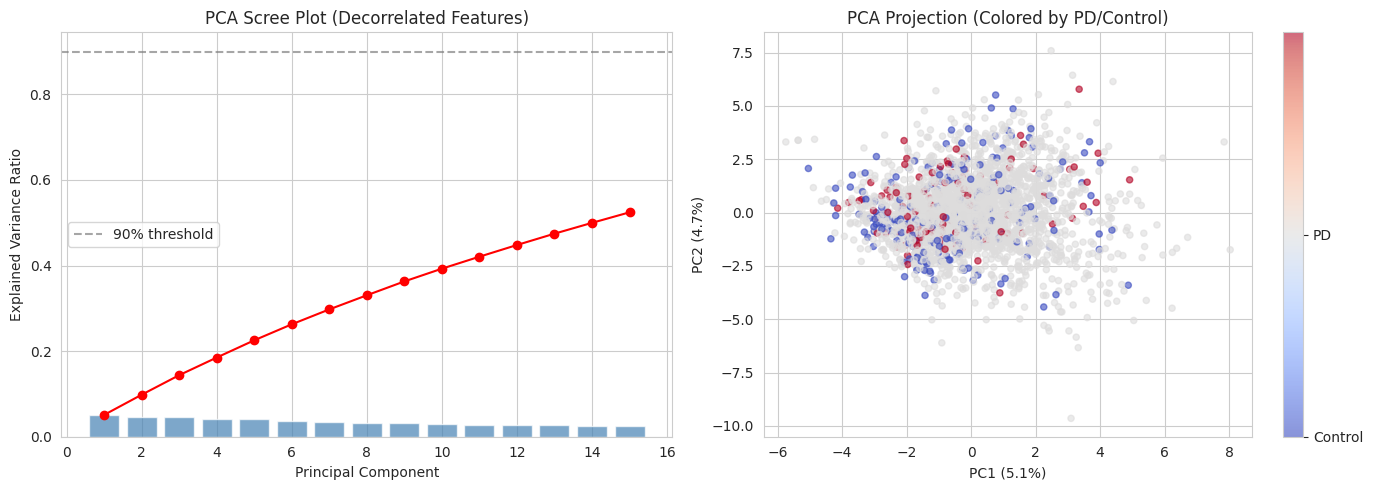

In [16]:
# Visualize PCA Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_model.explained_variance_ratio_)+1), 
            pca_model.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].plot(range(1, len(pca_model.explained_variance_ratio_)+1), 
             np.cumsum(pca_model.explained_variance_ratio_), 'ro-', markersize=6)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot (Decorrelated Features)')
axes[0].legend()

# PCA 2D Projection colored by label
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels_encoded, 
                          cmap='coolwarm', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA Projection (Colored by PD/Control)')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Control', 'PD'])

plt.tight_layout()
plt.show()

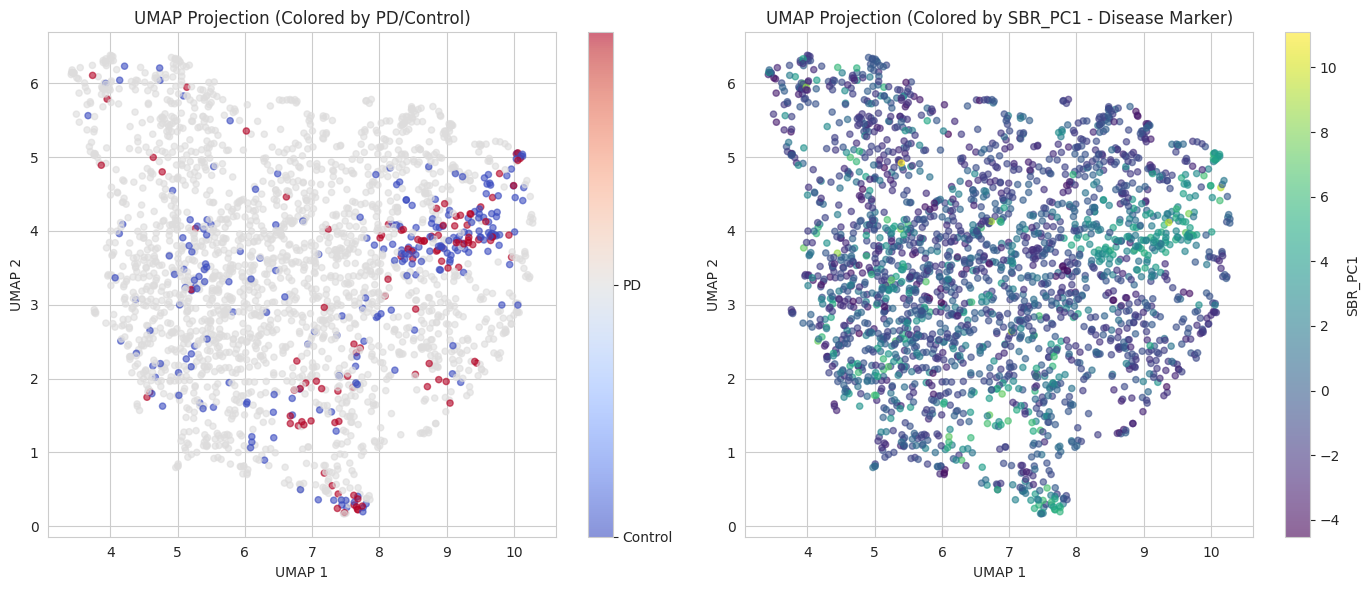

In [17]:
# UMAP Visualization (if available)
if X_umap is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Colored by Disease Status
    scatter1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=true_labels_encoded,
                               cmap='coolwarm', alpha=0.6, s=20)
    axes[0].set_xlabel('UMAP 1')
    axes[0].set_ylabel('UMAP 2')
    axes[0].set_title('UMAP Projection (Colored by PD/Control)')
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_ticks([0, 1])
    cbar1.set_ticklabels(['Control', 'PD'])
    
    # Colored by SBR_PC1 (disease severity marker)
    sbr_values = df_clean['SBR_PC1'].values
    scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=sbr_values,
                               cmap='viridis', alpha=0.6, s=20)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title('UMAP Projection (Colored by SBR_PC1 - Disease Marker)')
    plt.colorbar(scatter2, ax=axes[1], label='SBR_PC1')
    
    plt.tight_layout()
    plt.show()
else:
    print("UMAP not available. Skipping visualization.")

## 4. Optimal Cluster Selection

We use multiple methods to determine the optimal number of clusters:
- Elbow Method (Inertia)
- Silhouette Score
- Gap Statistic

In [18]:
def compute_gap_statistic(X, k_range, n_refs=10):
    """
    Compute Gap Statistic for optimal k selection.
    """
    gaps = []
    sks = []
    
    for k in k_range:
        # Fit K-Means on actual data
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(X)
        orig_disp = km.inertia_
        
        # Reference dispersions
        ref_disps = []
        for _ in range(n_refs):
            # Generate random reference data
            random_ref = np.random.random_sample(size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            km_ref.fit(random_ref)
            ref_disps.append(km_ref.inertia_)
        
        gap = np.mean(np.log(ref_disps)) - np.log(orig_disp)
        sk = np.std(np.log(ref_disps)) * np.sqrt(1 + 1/n_refs)
        gaps.append(gap)
        sks.append(sk)
    
    return np.array(gaps), np.array(sks)

def find_optimal_k(X, k_range=range(2, 11)):
    """
    Find optimal k using multiple methods.
    """
    inertias = []
    silhouettes = []
    
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    
    # Gap statistic
    gaps, sks = compute_gap_statistic(X, k_range, n_refs=5)
    
    return list(k_range), inertias, silhouettes, gaps, sks

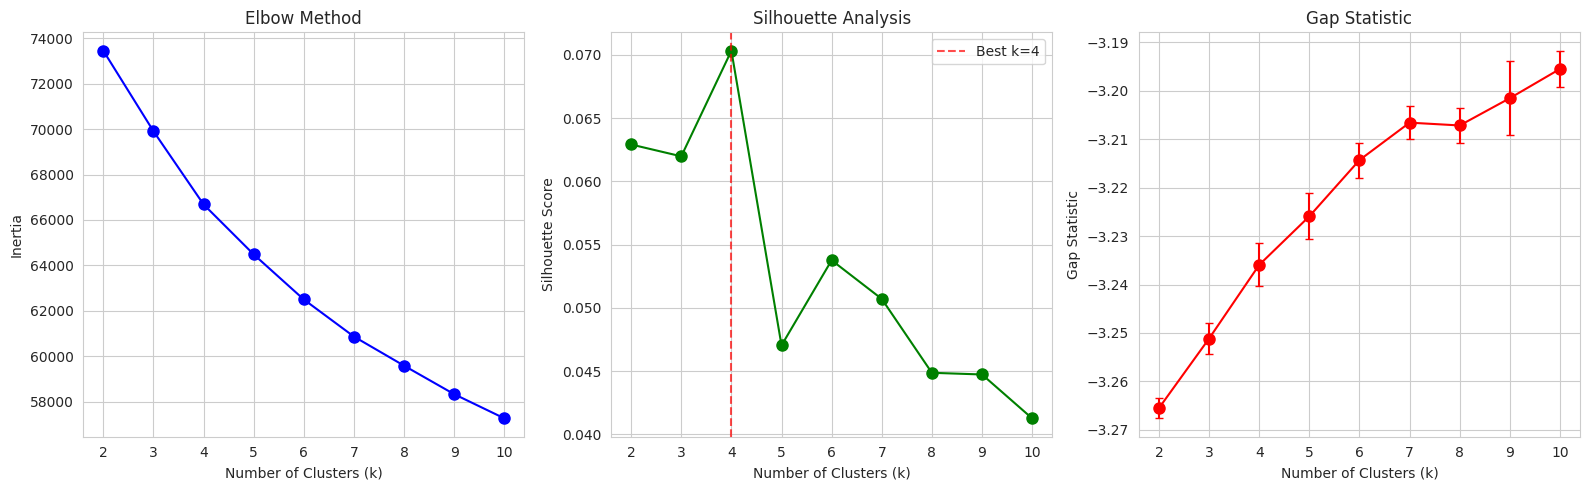


Optimal k by Silhouette Score: 4
Silhouette scores: {2: '0.0629', 3: '0.0620', 4: '0.0703', 5: '0.0470', 6: '0.0538', 7: '0.0507', 8: '0.0449', 9: '0.0447', 10: '0.0413'}


In [19]:
# Find optimal k using PCA-reduced data
k_range = range(2, 11)
ks, inertias, silhouettes, gaps, sks = find_optimal_k(X_pca, k_range)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow plot
axes[0].plot(ks, inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# Silhouette plot
axes[1].plot(ks, silhouettes, 'go-', markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
best_k_sil = ks[np.argmax(silhouettes)]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, 
                label=f'Best k={best_k_sil}')
axes[1].legend()

# Gap statistic
axes[2].errorbar(ks, gaps, yerr=sks, fmt='ro-', markersize=8, capsize=3)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Gap Statistic')
axes[2].set_title('Gap Statistic')

plt.tight_layout()
plt.show()

print(f"\nOptimal k by Silhouette Score: {best_k_sil}")
print(f"Silhouette scores: {dict(zip(ks, [f'{s:.4f}' for s in silhouettes]))}")

## 5. Clustering Experiments

We run multiple clustering algorithms and evaluate their performance.

In [20]:
def run_clustering_experiments(X_pca, X_umap, true_labels, k_values=[2, 3, 4, 5]):
    """
    Run multiple clustering algorithms and evaluate.
    """
    results = []
    cluster_assignments = {}
    
    for k in k_values:
        # 1. K-Means on PCA
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km_labels = km.fit_predict(X_pca)
        results.append({
            'Algorithm': 'KMeans',
            'Input': 'PCA',
            'k': k,
            'Silhouette': silhouette_score(X_pca, km_labels),
            'ARI': adjusted_rand_score(true_labels, km_labels)
        })
        cluster_assignments[f'KMeans_PCA_k{k}'] = km_labels
        
        # 2. GMM on PCA
        gmm = GaussianMixture(n_components=k, covariance_type='full', 
                              random_state=RANDOM_STATE, n_init=5)
        gmm_labels = gmm.fit_predict(X_pca)
        results.append({
            'Algorithm': 'GMM',
            'Input': 'PCA',
            'k': k,
            'Silhouette': silhouette_score(X_pca, gmm_labels),
            'ARI': adjusted_rand_score(true_labels, gmm_labels)
        })
        cluster_assignments[f'GMM_PCA_k{k}'] = gmm_labels
        
        # 3. Agglomerative Clustering on PCA
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        agg_labels = agg.fit_predict(X_pca)
        results.append({
            'Algorithm': 'Agglomerative',
            'Input': 'PCA',
            'k': k,
            'Silhouette': silhouette_score(X_pca, agg_labels),
            'ARI': adjusted_rand_score(true_labels, agg_labels)
        })
        cluster_assignments[f'Agg_PCA_k{k}'] = agg_labels
        
        # 4. If UMAP available, cluster on UMAP
        if X_umap is not None:
            km_umap = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            km_umap_labels = km_umap.fit_predict(X_umap)
            results.append({
                'Algorithm': 'KMeans',
                'Input': 'UMAP',
                'k': k,
                'Silhouette': silhouette_score(X_umap, km_umap_labels),
                'ARI': adjusted_rand_score(true_labels, km_umap_labels)
            })
            cluster_assignments[f'KMeans_UMAP_k{k}'] = km_umap_labels
    
    return pd.DataFrame(results), cluster_assignments

In [21]:
# Run experiments
df_results, cluster_assignments = run_clustering_experiments(
    X_pca, X_umap, true_labels_encoded, k_values=[2, 3, 4, 5, 6]
)

print("\n" + "="*70)
print("CLUSTERING RESULTS SUMMARY")
print("="*70)

# Sort by ARI
df_results_sorted = df_results.sort_values(by='ARI', ascending=False)
print(df_results_sorted.head(15).to_string(index=False))

# Best model
best_model = df_results_sorted.iloc[0]
print(f"\n>>> Best Model: {best_model['Algorithm']} on {best_model['Input']} with k={best_model['k']}")
print(f"    ARI: {best_model['ARI']:.4f}, Silhouette: {best_model['Silhouette']:.4f}")


CLUSTERING RESULTS SUMMARY
    Algorithm Input  k  Silhouette    ARI
Agglomerative   PCA  2      0.0329 0.0557
       KMeans  UMAP  2      0.4014 0.0301
       KMeans   PCA  2      0.0629 0.0280
          GMM   PCA  3      0.0152 0.0280
          GMM   PCA  5      0.0076 0.0274
       KMeans   PCA  4      0.0703 0.0254
          GMM   PCA  6     -0.0035 0.0235
Agglomerative   PCA  4      0.0451 0.0232
          GMM   PCA  4      0.0208 0.0220
Agglomerative   PCA  3      0.0410 0.0206
       KMeans   PCA  3      0.0620 0.0160
       KMeans  UMAP  6      0.3840 0.0148
       KMeans   PCA  5      0.0470 0.0146
       KMeans  UMAP  4      0.3803 0.0086
       KMeans  UMAP  5      0.3868 0.0077

>>> Best Model: Agglomerative on PCA with k=2
    ARI: 0.0557, Silhouette: 0.0329


## 6. Hierarchical Clustering Dendrogram

Visualize patient relationships using hierarchical clustering.

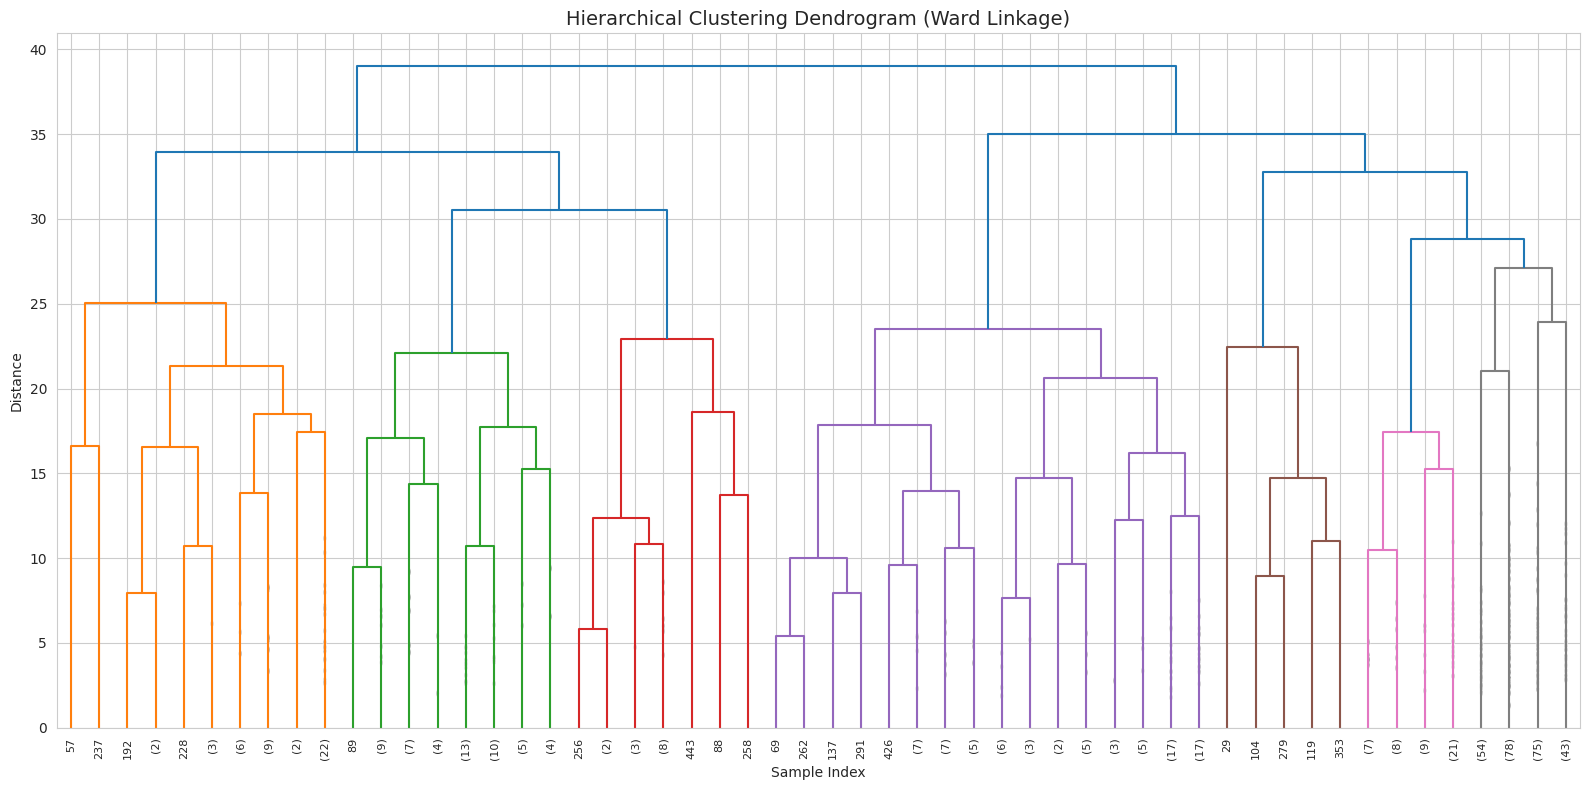

In [22]:
# Compute linkage matrix (using subset for visualization)
# Sample if too many patients
n_samples = min(500, len(X_pca))
sample_idx = np.random.choice(len(X_pca), n_samples, replace=False)

X_sample = X_pca[sample_idx]
labels_sample = true_labels_encoded[sample_idx]

# Compute linkage
Z = linkage(X_sample, method='ward')

# Create dendrogram
plt.figure(figsize=(16, 8))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Distance')

# Color leaves by PD/Control
dendrogram(
    Z,
    truncate_mode='level',
    p=5,  # Show only 5 levels
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)

plt.tight_layout()
plt.show()

## 7. Cluster Visualization

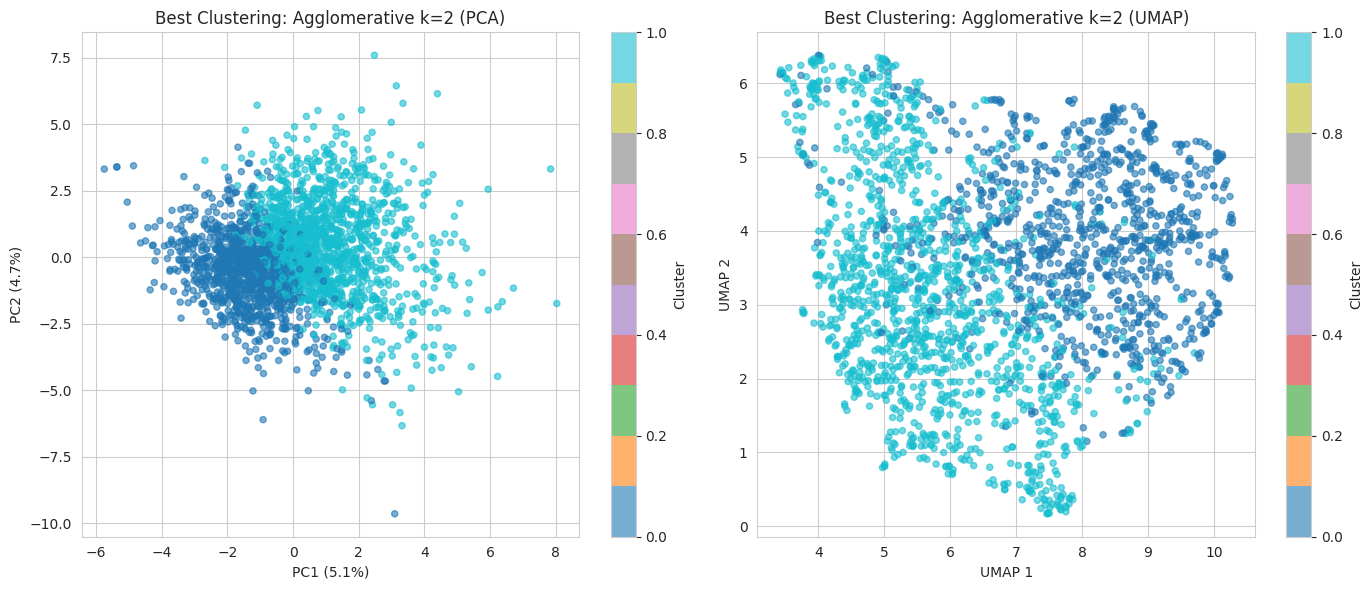

In [23]:
# Select best clustering result for visualization
best_key = f"{best_model['Algorithm']}_{'PCA' if best_model['Input'] == 'PCA' else 'UMAP'}_k{int(best_model['k'])}"
best_labels = cluster_assignments.get(best_key, cluster_assignments[list(cluster_assignments.keys())[0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA projection with cluster labels
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, 
                           cmap='tab10', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'Best Clustering: {best_model["Algorithm"]} k={int(best_model["k"])} (PCA)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# UMAP projection with cluster labels (if available)
if X_umap is not None:
    scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=best_labels,
                               cmap='tab10', alpha=0.6, s=20)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title(f'Best Clustering: {best_model["Algorithm"]} k={int(best_model["k"])} (UMAP)')
    plt.colorbar(scatter2, ax=axes[1], label='Cluster')
else:
    # Show true labels instead
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels_encoded,
                               cmap='coolwarm', alpha=0.6, s=20)
    axes[1].set_xlabel(f'PC1')
    axes[1].set_ylabel(f'PC2')
    axes[1].set_title('True Labels (PD/Control)')
    cbar = plt.colorbar(scatter2, ax=axes[1])
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Control', 'PD'])

plt.tight_layout()
plt.show()

## 8. Clinical Profiling of Clusters

**Critical Analysis**: Do the clusters correspond to clinically meaningful subtypes?

In [24]:
# Add cluster labels to dataframe
df_clean['Cluster'] = best_labels

# Define clinical variables for profiling
CLINICAL_VARS = {
    'Age': {'col': 'AGE_AT_VISIT', 'type': 'continuous'},
    'Sex': {'col': 'SEX', 'type': 'categorical'},
    'Handedness': {'col': 'HANDED', 'type': 'categorical'},
    'Scanner': {'col': 'Manufacturer', 'type': 'categorical'},
    'Scanner Model': {'col': 'ManufacturerModelName', 'type': 'categorical'},
    'SBR_PC1': {'col': 'SBR_PC1', 'type': 'continuous'},
    'SBR_PC2': {'col': 'SBR_PC2', 'type': 'continuous'},
    'SBR_PC3': {'col': 'SBR_PC3', 'type': 'continuous'},
}

# Compute cluster profiles
profile_data = []

for cluster_id in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    profile = {'Cluster': cluster_id, 'N': len(cluster_data)}
    
    for var_name, var_config in CLINICAL_VARS.items():
        col = var_config['col']
        if var_config['type'] == 'continuous':
            profile[f'{var_name}_Mean'] = cluster_data[col].mean()
            profile[f'{var_name}_Std'] = cluster_data[col].std()
        else:
            # For categorical, show mode/proportion
            mode = cluster_data[col].mode().iloc[0] if len(cluster_data[col].mode()) > 0 else 'N/A'
            profile[f'{var_name}_Mode'] = mode
            if col == 'label':
                pd_prop = (cluster_data[col] == 'PD').mean()
                profile['PD_Proportion'] = pd_prop
    
    profile_data.append(profile)

df_profile = pd.DataFrame(profile_data)
print("\n" + "="*80)
print("CLUSTER CLINICAL PROFILES")
print("="*80)
print(df_profile.to_string(index=False))


CLUSTER CLINICAL PROFILES
 Cluster    N  Age_Mean  Age_Std  Sex_Mode  Handedness_Mode Scanner_Mode Scanner Model_Mode  SBR_PC1_Mean  SBR_PC1_Std  SBR_PC2_Mean  SBR_PC2_Std  SBR_PC3_Mean  SBR_PC3_Std
       0 1033   62.3751  10.3096    1.0000           1.0000   SIEMENS NM            Encore2        0.0266       2.2668        0.0408       0.5520       -0.0368       0.4875
       1 1340   64.1495   9.5038    1.0000           1.0000   SIEMENS NM            Encore2       -0.0205       2.3307       -0.0315       0.5693        0.0284       0.5718


In [25]:
# Statistical tests: Do clusters differ significantly on clinical variables?
print("\n" + "="*80)
print("STATISTICAL TESTS FOR CLUSTER DIFFERENCES")
print("="*80)

n_clusters = df_clean['Cluster'].nunique()

for var_name, var_config in CLINICAL_VARS.items():
    col = var_config['col']
    
    if var_config['type'] == 'continuous':
        # ANOVA
        groups = [df_clean[df_clean['Cluster'] == c][col].dropna() for c in range(n_clusters)]
        if all(len(g) > 1 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
            sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
            print(f"{var_name}: F={f_stat:.2f}, p={p_val:.4e} {sig}")
    else:
        # Chi-squared test
        contingency = pd.crosstab(df_clean['Cluster'], df_clean[col])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
            sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
            print(f"{var_name}: χ²={chi2:.2f}, p={p_val:.4e} {sig}")


STATISTICAL TESTS FOR CLUSTER DIFFERENCES
Age: F=18.87, p=1.4610e-05 ***
Sex: χ²=0.79, p=3.7418e-01 
Handedness: χ²=7.73, p=2.0939e-02 *
Scanner: χ²=265.45, p=8.0617e-48 ***
Scanner Model: χ²=276.07, p=3.6563e-44 ***
SBR_PC1: F=0.24, p=6.2144e-01 
SBR_PC2: F=9.67, p=1.8956e-03 **
SBR_PC3: F=8.62, p=3.3583e-03 **


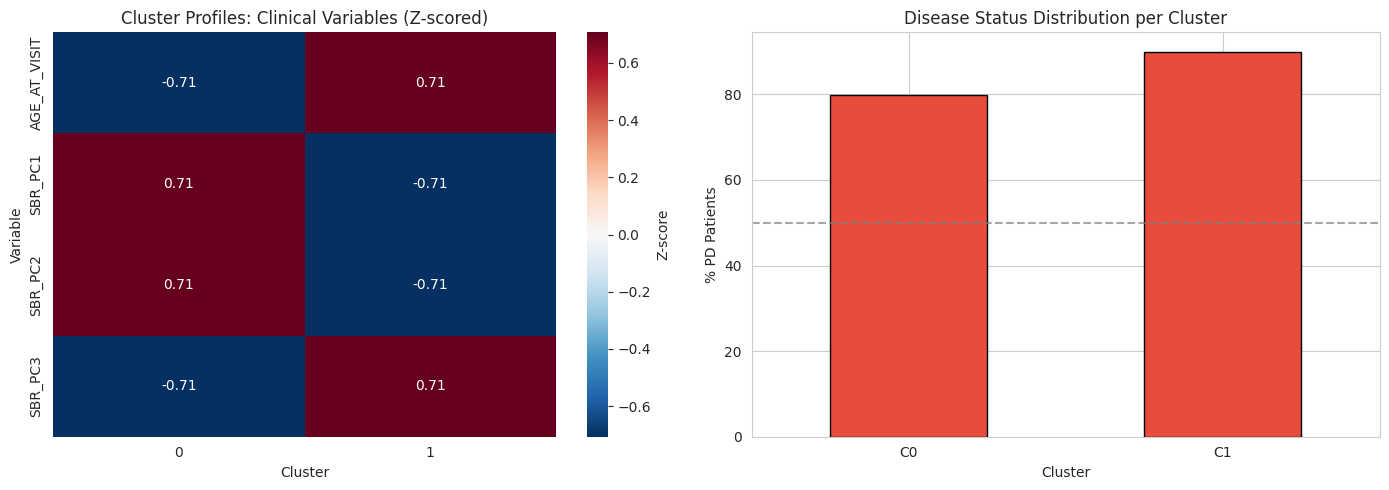

In [26]:
# Heatmap: Cluster vs Clinical Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for heatmap (continuous variables)
continuous_vars = ['AGE_AT_VISIT', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3']
heatmap_data = df_clean.groupby('Cluster')[continuous_vars].mean()

# Standardize for visualization
heatmap_data_scaled = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

sns.heatmap(heatmap_data_scaled.T, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[0], cbar_kws={'label': 'Z-score'})
axes[0].set_title('Cluster Profiles: Clinical Variables (Z-scored)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Variable')

# Bar chart: Disease status proportion per cluster
disease_props = df_clean.groupby('Cluster')['label'].apply(
    lambda x: (x == 'PD').mean() * 100
)
colors = ['#E74C3C' if p > 50 else '#3498DB' for p in disease_props]
disease_props.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% PD Patients')
axes[1].set_title('Disease Status Distribution per Cluster')
axes[1].set_xticklabels([f'C{i}' for i in range(n_clusters)], rotation=0)

plt.tight_layout()
plt.show()

## 9. Cluster Stability Analysis (Bootstrap Consensus)

Test whether clusters are stable across different samples.

In [27]:
def bootstrap_consensus_clustering(X, k, n_bootstrap=50, sample_frac=0.8):
    """
    Perform bootstrap consensus clustering.
    Returns co-association matrix.
    """
    n_samples = X.shape[0]
    co_assoc = np.zeros((n_samples, n_samples))
    sample_count = np.zeros((n_samples, n_samples))
    
    for i in range(n_bootstrap):
        # Bootstrap sample
        sample_idx = np.random.choice(n_samples, int(n_samples * sample_frac), replace=False)
        X_sample = X[sample_idx]
        
        # Cluster
        km = KMeans(n_clusters=k, random_state=i, n_init=10)
        labels = km.fit_predict(X_sample)
        
        # Update co-association
        for j, idx1 in enumerate(sample_idx):
            for l, idx2 in enumerate(sample_idx):
                sample_count[idx1, idx2] += 1
                if labels[j] == labels[l]:
                    co_assoc[idx1, idx2] += 1
    
    # Normalize
    mask = sample_count > 0
    co_assoc[mask] = co_assoc[mask] / sample_count[mask]
    
    return co_assoc

# Run bootstrap (reduced for speed - increase n_bootstrap for production)
print("Running Bootstrap Consensus Clustering (this may take a moment)...")
co_assoc_matrix = bootstrap_consensus_clustering(X_pca, k=int(best_model['k']), 
                                                  n_bootstrap=30, sample_frac=0.8)
print("Done!")

Running Bootstrap Consensus Clustering (this may take a moment)...
Done!


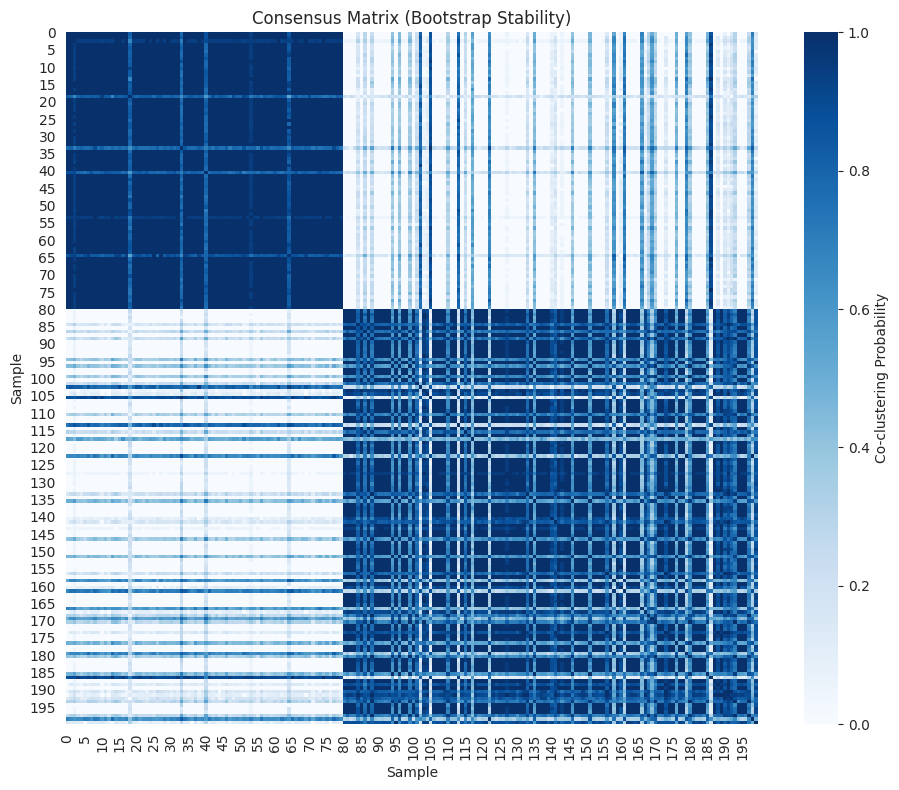


Cluster Stability Scores (higher = more stable):
  Cluster 0: 0.965
  Cluster 1: 0.786
  Average: 0.876


In [28]:
# Visualize consensus matrix (subsample for clarity)
n_show = min(200, len(co_assoc_matrix))
show_idx = np.random.choice(len(co_assoc_matrix), n_show, replace=False)
show_idx = np.sort(show_idx)

# Reorder by cluster assignment
order = np.argsort(best_labels[show_idx])
show_idx_ordered = show_idx[order]

plt.figure(figsize=(10, 8))
sns.heatmap(co_assoc_matrix[np.ix_(show_idx_ordered, show_idx_ordered)], 
            cmap='Blues', square=True, cbar_kws={'label': 'Co-clustering Probability'})
plt.title('Consensus Matrix (Bootstrap Stability)')
plt.xlabel('Sample')
plt.ylabel('Sample')
plt.tight_layout()
plt.show()

# Compute stability score (average within-cluster co-association)
stability_scores = []
for c in range(int(best_model['k'])):
    mask = best_labels == c
    within_cluster = co_assoc_matrix[np.ix_(mask, mask)]
    stability_scores.append(np.mean(within_cluster[np.triu_indices_from(within_cluster, k=1)]))

print(f"\nCluster Stability Scores (higher = more stable):")
for c, score in enumerate(stability_scores):
    print(f"  Cluster {c}: {score:.3f}")
print(f"  Average: {np.mean(stability_scores):.3f}")

## 10. Final Summary & Interpretation

In [29]:
print("="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)

print(f"\n1. DATA:")
print(f"   - Total samples: {len(df_clean)}")
print(f"   - Unique patients: {df_clean['PATNO'].nunique()}")
print(f"   - Features used: {len(SET_B)} (decorrelated from confounders)")

print(f"\n2. DIMENSIONALITY REDUCTION:")
print(f"   - PCA: {X_pca.shape[1]} components, {pca_model.explained_variance_ratio_.sum():.1%} variance")
if X_umap is not None:
    print(f"   - UMAP: 2D manifold embedding")

print(f"\n3. BEST CLUSTERING MODEL:")
print(f"   - Algorithm: {best_model['Algorithm']}")
print(f"   - Number of clusters: {int(best_model['k'])}")
print(f"   - Silhouette Score: {best_model['Silhouette']:.4f}")
print(f"   - Adjusted Rand Index: {best_model['ARI']:.4f}")

print(f"\n4. CLUSTER STABILITY:")
print(f"   - Average stability: {np.mean(stability_scores):.3f}")

print(f"\n5. CLINICAL INTERPRETATION:")
for c in range(int(best_model['k'])):
    cluster_data = df_clean[df_clean['Cluster'] == c]
    pd_pct = (cluster_data['label'] == 'PD').mean() * 100
    sbr_mean = cluster_data['SBR_PC1'].mean()
    age_mean = cluster_data['AGE_AT_VISIT'].mean()
    print(f"   Cluster {c}: N={len(cluster_data)}, PD%={pd_pct:.1f}%, Age={age_mean:.1f}, SBR_PC1={sbr_mean:.2f}")

print("\n" + "="*80)
print("CONCLUSIONS:")
print("="*80)
if best_model['ARI'] < 0.15:
    print(">>> The clusters do NOT strongly align with PD/Control labels (low ARI).")
    print(">>> This may indicate:")
    print("    a) Subtypes exist WITHIN PD patients that cross diagnostic boundaries")
    print("    b) The latent space captures variability not directly related to disease")
    print("    c) More sophisticated methods (e.g., supervised subtyping) may be needed")
else:
    print(">>> The clusters show meaningful alignment with clinical labels.")
    print(">>> Consider profiling these subtypes for clinical translation.")

if best_model['Silhouette'] < 0.15:
    print("\n>>> Low Silhouette Score indicates poor cluster separation.")
    print(">>> The patient population may not have distinct, separable subtypes.")

FINAL ANALYSIS SUMMARY

1. DATA:
   - Total samples: 2373
   - Unique patients: 1437
   - Features used: 63 (decorrelated from confounders)

2. DIMENSIONALITY REDUCTION:
   - PCA: 15 components, 52.4% variance
   - UMAP: 2D manifold embedding

3. BEST CLUSTERING MODEL:
   - Algorithm: Agglomerative
   - Number of clusters: 2
   - Silhouette Score: 0.0329
   - Adjusted Rand Index: 0.0557

4. CLUSTER STABILITY:
   - Average stability: 0.876

5. CLINICAL INTERPRETATION:
   Cluster 0: N=1033, PD%=79.8%, Age=62.4, SBR_PC1=0.03
   Cluster 1: N=1340, PD%=90.0%, Age=64.1, SBR_PC1=-0.02

CONCLUSIONS:
>>> The clusters do NOT strongly align with PD/Control labels (low ARI).
>>> This may indicate:
    a) Subtypes exist WITHIN PD patients that cross diagnostic boundaries
    b) The latent space captures variability not directly related to disease
    c) More sophisticated methods (e.g., supervised subtyping) may be needed

>>> Low Silhouette Score indicates poor cluster separation.
>>> The patient 

In [30]:
# Save results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Save clustering results
df_results.to_csv(f"{output_dir}/clustering_results_v2.csv", index=False)
df_profile.to_csv(f"{output_dir}/cluster_profiles_v2.csv", index=False)

# Save patient cluster assignments
df_clean[['PATNO', 'label', 'Cluster', 'AGE_AT_VISIT', 'SBR_PC1', 'SBR_PC2']].to_csv(
    f"{output_dir}/patient_cluster_assignments_v2.csv", index=False
)

print(f"\nResults saved to {output_dir}/")


Results saved to output/
